In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
path = 'https://frenzy86.s3.eu-west-2.amazonaws.com/fav/tecno/titanic.csv'
df=pd.read_csv(path,sep="\t")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,C2,S
152,153,0,3,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.0500,NaN,S
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S
154,155,0,3,"Olsen, Mr. Ole Martin",male,NaN,0,0,Fa 265302,7.3125,NaN,S


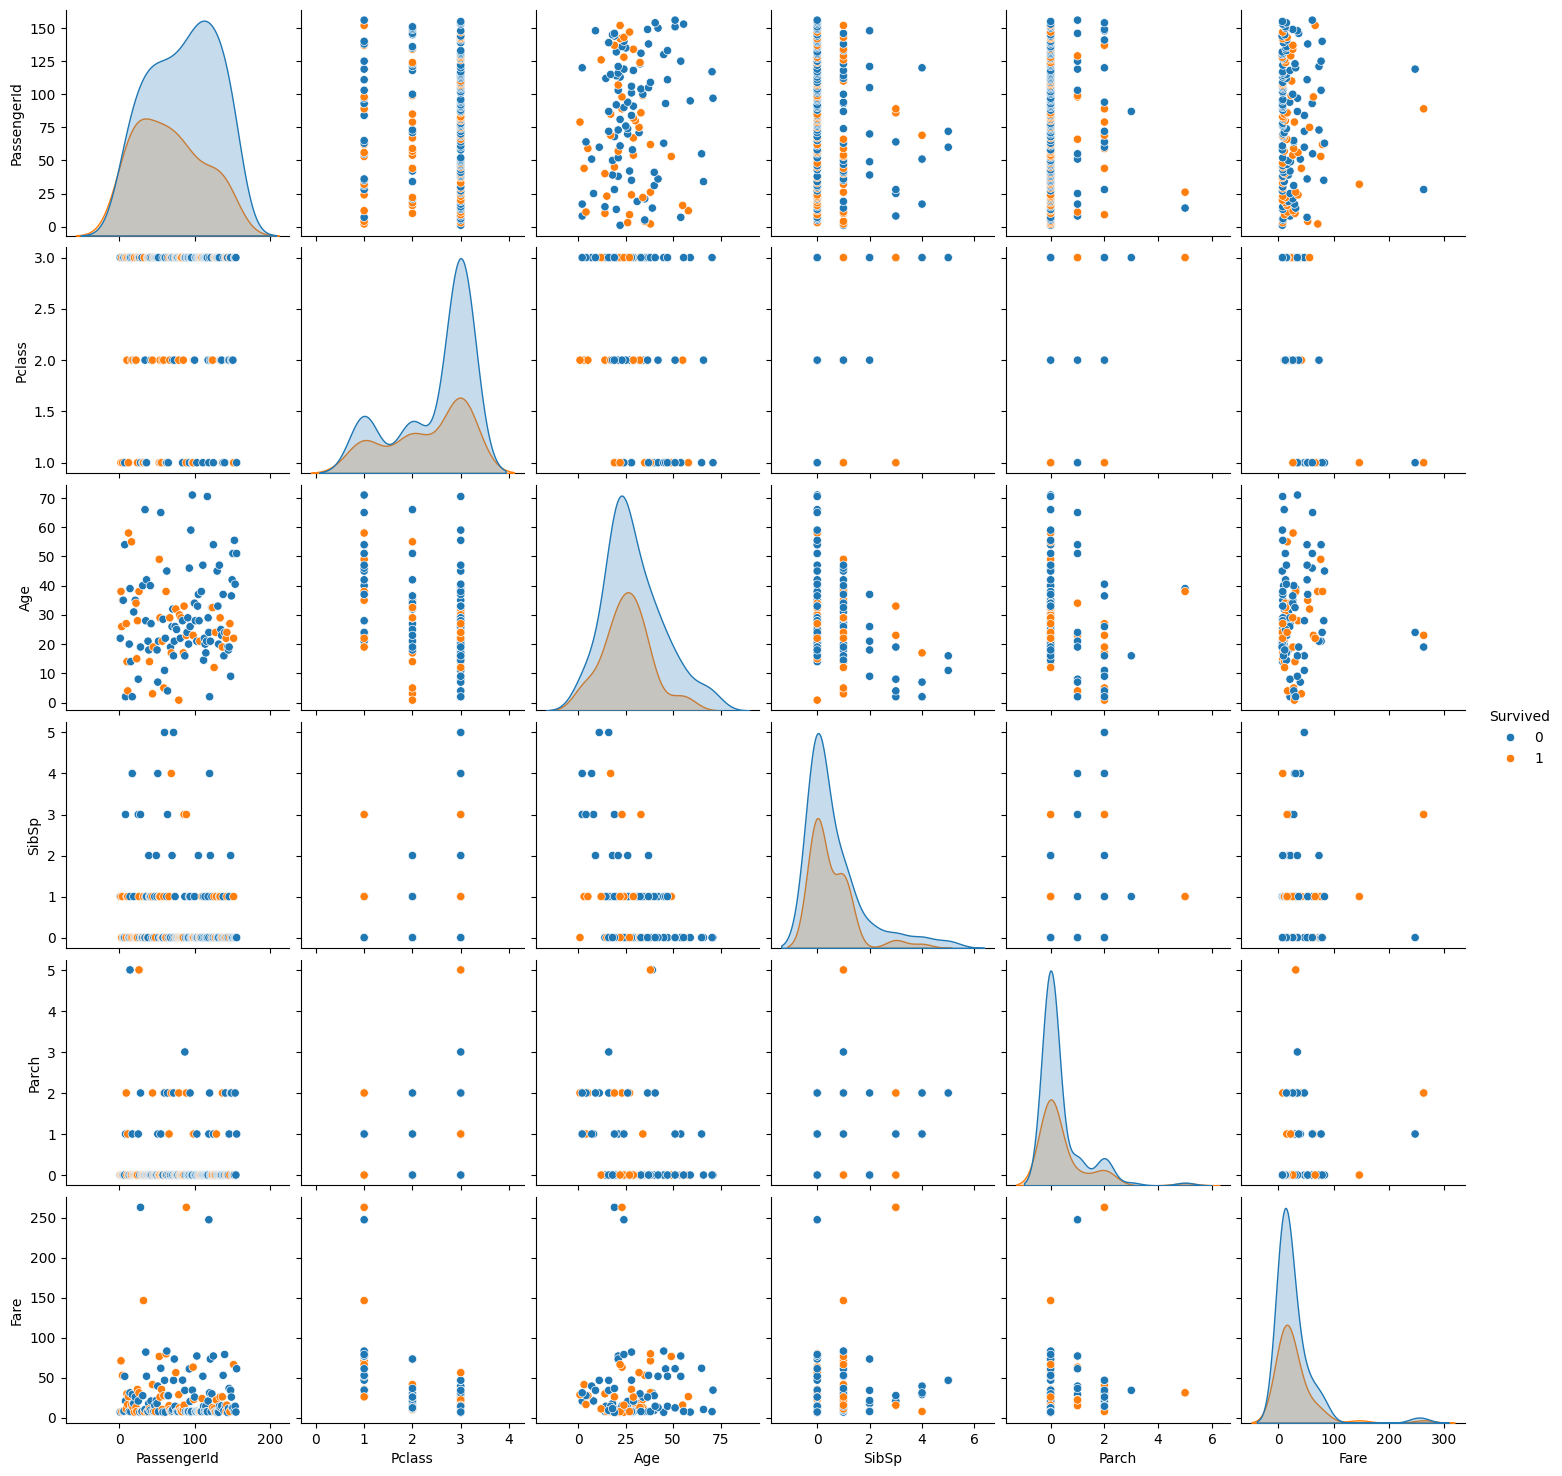

In [7]:
sns.pairplot(df,hue="Survived")

In [8]:
df=df.drop(columns=["PassengerId","Name","Cabin","Ticket"])
df["Sex"]=df["Sex"].map({"male":1,"female":0})
df.rename(columns={"Sex": "male"}, inplace=True)
df

,Survived,Pclass,male,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
151,1,1,0,22.0,1,0,66.6000,S
152,0,3,1,55.5,0,0,8.0500,S
153,0,3,1,40.5,0,2,14.5000,S
154,0,3,1,NaN,0,0,7.3125,S


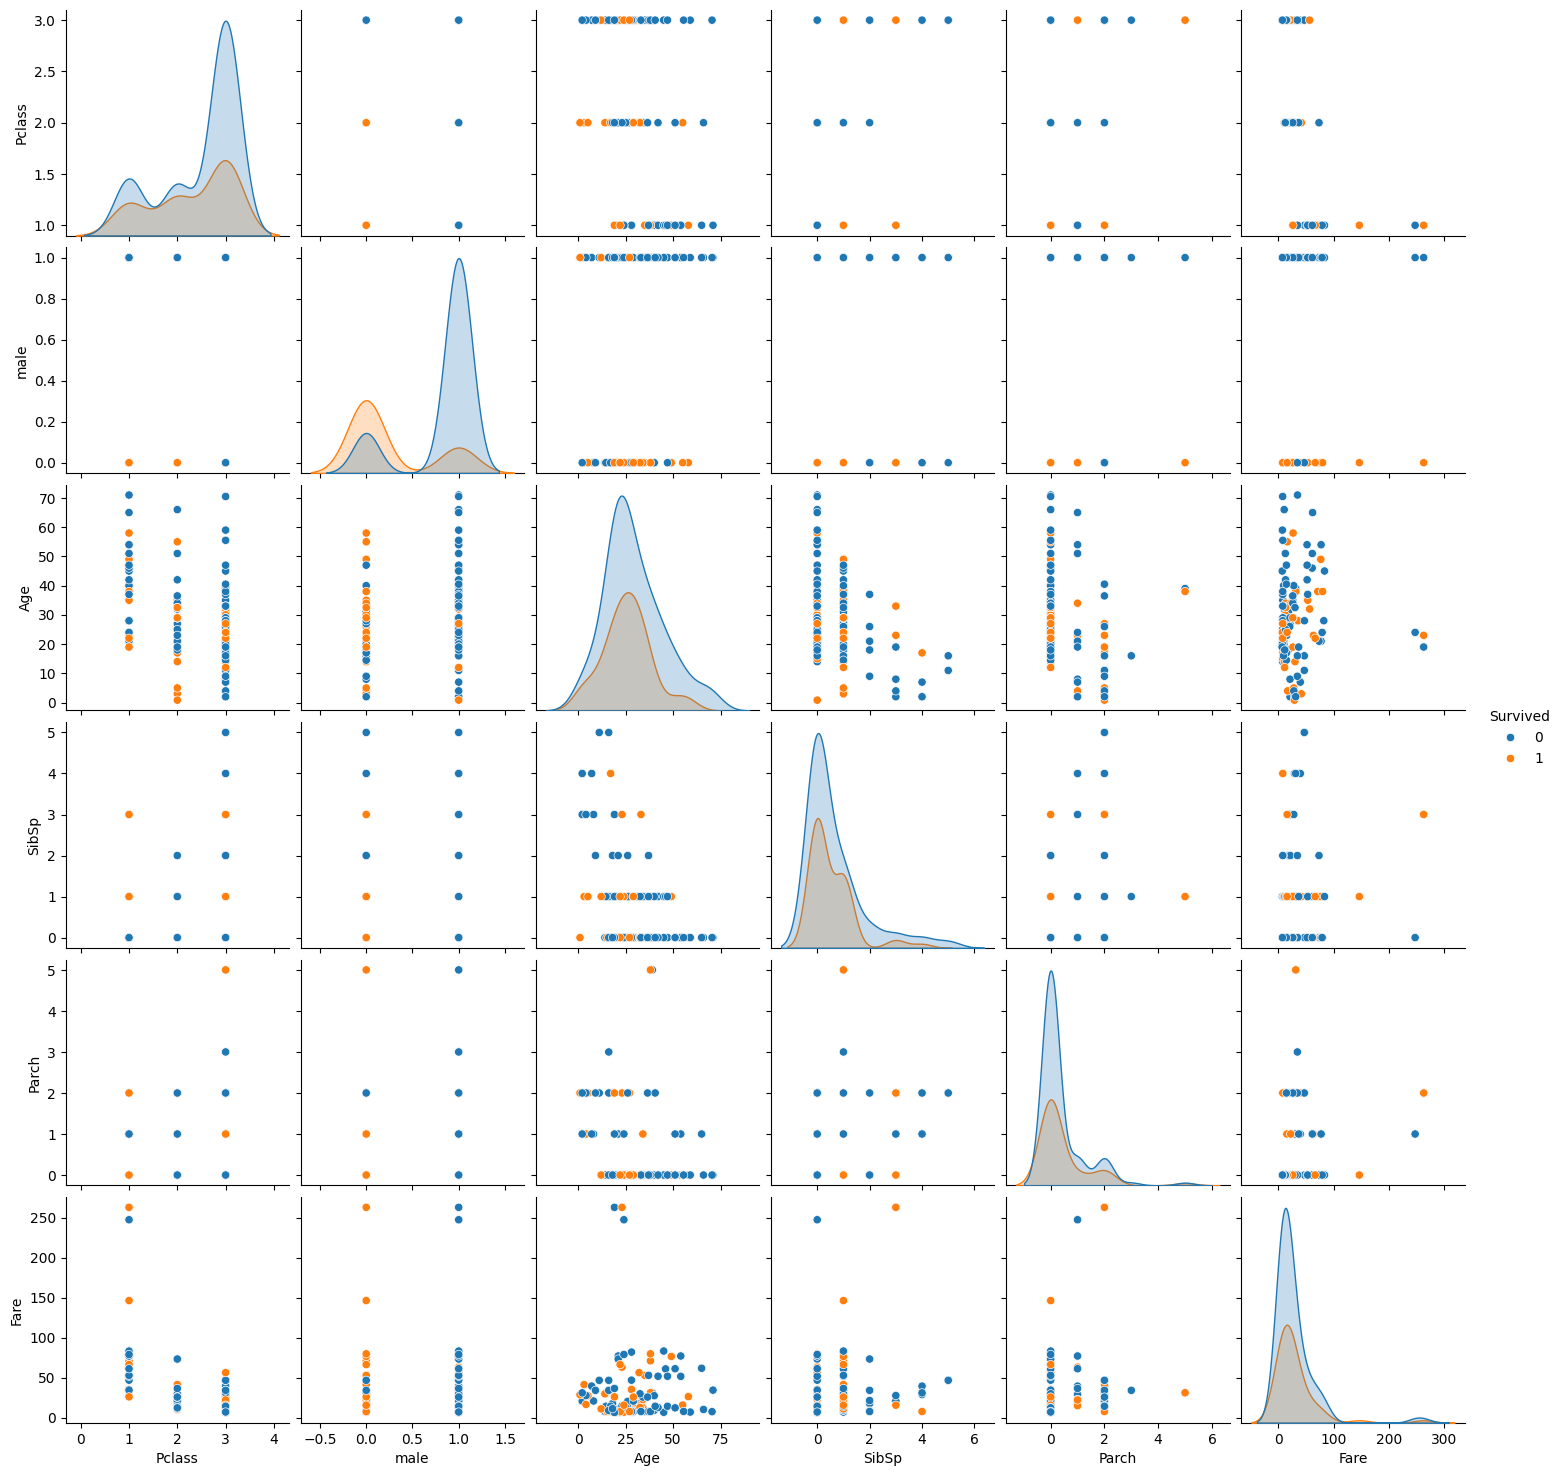

In [9]:
sns.pairplot(df,hue="Survived")

In [10]:
df.isnull().sum()

Survived     0
Pclass       0
male         0
Age         30
SibSp        0
Parch        0
Fare         0
Embarked     1
dtype: int64

In [11]:
df["Age"]=df["Age"].interpolate()

In [12]:
df.isnull().sum()

Survived    0
Pclass      0
male        0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    1
dtype: int64

In [13]:
df=df.dropna()

In [14]:
from summarytools import dfSummary
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,Survived[int64],Mean (sd) : 0.3 (0.5)min < med < max:0.0 < 0.0 < 1.0IQR (CV) : 1.0 (0.7),2 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABf0lEQVR4nO3cQWrCQBiG4ZkiopsEETyMh+hhewhvI2VcVClouuumUGNU2g+eZ535yeIlYTZ/HYahwH/38tcvAGPMrj1Qa12WUuYT538Ow3CceBa+/RpqrXW5Xq9fu65bTRl+OBzea61vYuVe176o867rVtvt9tj3/emWwa21xW63W+33+3kpRajc5eqvv5RS+r4/bTabjwnzlxPOwA8uU0QQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESgShEmHUkjQY45m7dIXKQzx7l65QeZSn7tIVKg/1rF26LlNEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESoRR+1Fba4tbB7fWFufzeVZK6WqtN78YcbrL5TKb2sq1Z74AKnBOfXzSxlwAAAAASUVORK5CYII="">",0(0.0%)
2,Pclass[int64],Mean (sd) : 2.4 (0.8)min < med < max:1.0 < 3.0 < 3.0IQR (CV) : 1.0 (3.1),3 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABjklEQVR4nO3dUWrqQBiG4ZkiojcJIrgYF9HFdhHuRsp4cVoOaLqCVk0Nnu/keW7jhPHnRQwEpg7DUOBf9/LsDcAtFs/eAP+PWuu6lLIcufzvMAwf310UKg9Ra11vt9vXrus2Y9afTqf3Wuvbd7EKlUdZdl232e/3H33ff96zsLW2OhwOm+PxuCylCJXp9X3/udvt/oxYuv7poocpIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIjpicwJSnLM/V1VAN/T5Tn7I8Vz+GauijTHrK8lxd+0U19JGmOmV5rm76j2roPJunfiIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiXDTi9OttdW9N26trc7n86KU0tVa795YsO5yuSxmOLNffe9rn/kCBON2/PUoVfEAAAAASUVORK5CYII="">",0(0.0%)
3,male[int64],Mean (sd) : 0.6 (0.5)min < med < max:0.0 < 1.0 < 1.0IQR (CV) : 1.0 (1.3),2 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABe0lEQVR4nO3cQWrCQBiG4ZkiopsEETyMh+hhewhvI2VcVCloegJrFIP9yvNskz/M4iUwm78Ow1Dgr3t79QFgjNmrD8D/UWtdllLmD45/D8NwvPZQqDxFrXW5Xq/fu65bPTJ/OBw+a60f12IVKs8y77putd1uj33fn+4ZbK0tdrvdar/fz0spQmV6fd+fNpvN1wOjy98eukwRQahEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEuLnSZ8oNbTDWr6FOvaENxrr1R510QxuMNWqb31Qb2mAslykiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIozaON1aW9z74dba4nw+z0opXa317oMRp7tcLrNHW7n1zg/49k59mv1ZAQAAAABJRU5ErkJggg=="">",0(0.0%)
4,Age[float64],Mean (sd) : 28.2 (14.4)min < med < max:0.8 < 26.0 < 71.0IQR (CV) : 16.0 (2.0),77 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACyUlEQVR4nO3dTY7aMBiA4c9lgPAjRwgJdlygUhcsc4g5bI8wC07ADdghIQSCAREC3ZRKVRkgtlPyhffZG6LRO56x4yjmfD4LUHbfnn0BwCPenn0BtxhjWiLScBx+OJ/Pu5DXg+cpbajGmFa/33+31vZcxq/X66Ux5iexVkNpQxWRhrW2lyTJLo7jfZ6Bq9UqmkwmvcVi0RARQq2AMocqIiJxHO8Hg8Gnw9BW8IvB07CYggqEChVK/6ffVZZldRGxxhjXj2DXoEQqGep2u62nafpjNBrVarVaroXYBbsG5VLJUA+Hw1sURe3xeLwfDofLvOPZNSifSoZ60el0XHcMRNg1KBUWU1CBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFChUrf6/fheUyQI4KBEeoVvscEOSIYHqFe4XNMkCOCxSDUGzyOCXJEMDAWU1CBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFCBUKFCoQKFQgVKhAqVCBUqECoUIFQoQKhQgWemSoAj1qHR6iB8ah1MQg1MB61LgahFoRHrcNiMQUVCp1RjTEtEWk4Dren06ke8no04NWY1xUWqjGm1e/33621PZfxaZpGWZZ93+/3HyLi+lIzVXg15tfuhuoxK9putztIkmQdx3HuH/psNutNp9P28XisOXy3Srwa82s3Q/WZFS8zYrPZ/HBZVCyXy5ddVPBqzH/dm1Eb1tpekiS7vLPiK86IKM5D/6PGcZz7N/yVZ0SEx/YUVGDDv2Kqes6AUCukyucMCLVCnn3OwPMGz83ZnFAr6BnnDHxv8NybzQkVoThvZT4ymxMqgnLZyvzt5mxOqPjDc8eg0ENEhAoR8d8xKPoQEaFCRPwPxBR9y5xQ8RfXHYOib5lzCxUqPDSjrlarKO8HbzabSERku91G8/m8/T/Ha/1urdftO/6Rvn4BpaK+sJ65CT0AAAAASUVORK5CYII="">",0(0.0%)
5,SibSp[int64],Me

In [15]:
df=pd.get_dummies(df, columns=["Embarked"],drop_first=False, dtype=int)

In [16]:
df

,Survived,Pclass,male,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.00,1,0,7.2500,0,0,1
1,1,1,0,38.00,1,0,71.2833,1,0,0
2,1,3,0,26.00,0,0,7.9250,0,0,1
3,1,1,0,35.00,1,0,53.1000,0,0,1
4,0,3,1,35.00,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...
151,1,1,0,22.00,1,0,66.6000,0,0,1
152,0,3,1,55.50,0,0,8.0500,0,0,1
153,0,3,1,40.50,0,2,14.5000,0,0,1
154,0,3,1,45.75,0,0,7.3125,0,0,1


In [17]:
target = "Survived"
X = df.drop([target],axis=1)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
standardized_data = sc.fit_transform(X)
X = standardized_data
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=667,
                                                    )

In [40]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [41]:
scores=cross_val_score(model,X,y,cv=5)
scores

array([0.83870968, 0.77419355, 0.83870968, 0.70967742, 0.67741935])

In [42]:
model.score(X_train,y_train)

0.8981481481481481

In [43]:
model.score(X_test,y_test)

0.7446808510638298

In [44]:
imp=model.feature_importances_
imp

array([0.05464993, 0.65968661, 0.16029518, 0.        , 0.        ,
       0.08046572, 0.        , 0.        , 0.04490256])

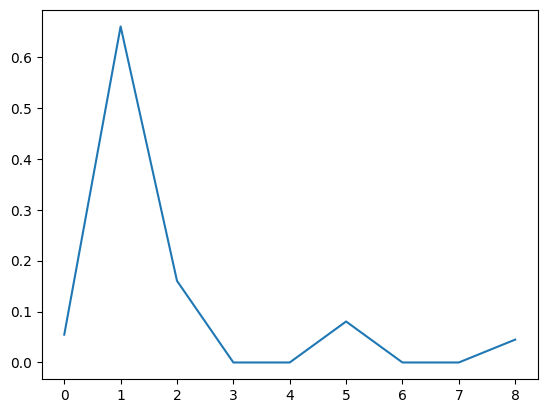

In [45]:
plt.plot(imp)

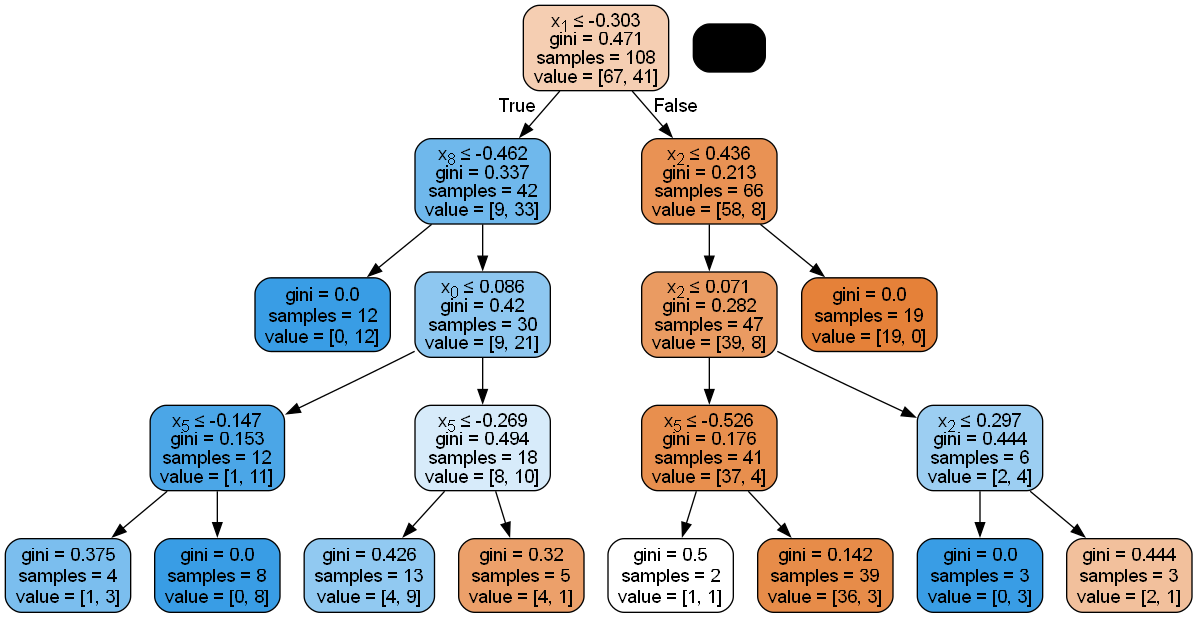

In [46]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

dot_data=StringIO()
export_graphviz(model,out_file=dot_data,filled=True,rounded=True,special_characters=True)
graph=pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())